In [13]:
import torch
import scipy.stats as stats
from sbi.inference import NPE,NLE
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

import numpy as np

from torch.distributions import Normal, Independent

In [14]:
num_dim = 1  # Here, num_dim = 1 because only mu is being inferred

def simulator(theta, n=100):
    # theta[0] is μ, theta[1] is σ
    mu, sigma2 = theta[0], 1
    sigma = np.sqrt(sigma2)
    return mu + sigma * torch.randn(n)  # Generate n observations

prior = Normal(torch.tensor([0.0]), torch.tensor([1.0]))


In [15]:
prior, num_parameters, prior_returns_numpy = process_prior(prior)

simulator = process_simulator(simulator, prior, prior_returns_numpy)

# Consistency check after making ready for sbi.
check_sbi_inputs(simulator, prior)


In [16]:
inference = NLE(prior=prior)
# get test data
num_simulations = 500
theta = prior.sample((num_simulations,))
x = simulator(theta)

In [17]:
inference = inference.append_simulations(theta, x)
density_estimator = inference.train()

 Neural network successfully converged after 181 epochs.

In [18]:
posterior = inference.build_posterior(density_estimator)

/opt/anaconda3/envs/SBI_project/lib/python3.11/site-packages/sbi/inference/posteriors/mcmc_posterior.py:115: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


In [19]:
theta_true = torch.tensor([[0.4]])  # μ = 0.3
x_obs = simulator(theta_true)
samples = posterior.sample((10000,), x=x_obs)

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

In [20]:


# Prior parameters
mu_0 = 0
sigma_0_sq = 1  # Prior variance

# Data preparation
Z = x_obs.numpy()  # If PyTorch tensor, convert to NumPy array
Z_flat = Z.flatten()  # Flatten to a one-dimensional array

# Sample mean and sample size
Y_mean = np.mean(Z_flat)  # Sample mean
n = Z.size  # Sample size

# Posterior mean μ'
mu_post = (mu_0 + n * Y_mean) / (1 + n)

# Posterior variance σ_post^2
sigma_post_sq = sigma_0_sq / (1 + n)

# Output results
print("Posterior Mean (mu_post):", mu_post)
print("Posterior Variance (sigma_post_sq):", sigma_post_sq)


Posterior Mean (mu_post): 0.3886288640522721
Posterior Variance (sigma_post_sq): 0.009900990099009901


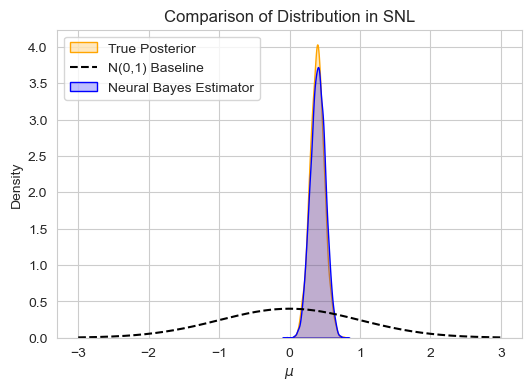

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Assume mu_post and sigma_post_sq are already defined
sigma_post = np.sqrt(sigma_post_sq)  # Posterior standard deviation
sigma_prior_sq = 1
mu_prior = 0
sigma_prior = np.sqrt(sigma_prior_sq)

# Generate samples from the Posterior distribution
num_samples = 1000  # Number of samples
mu_samples = np.random.normal(loc=mu_post, scale=sigma_post, size=num_samples)

plt.figure(figsize=(6, 4))

# Plot KDE for the Posterior samples
sns.kdeplot(mu_samples, label="True Posterior", fill=True, color="orange")

# Generate density curve for N(0,1)
x = np.linspace(-3, 3, 1000)  # Set x-axis range
y = stats.norm.pdf(x, loc=0, scale=1)  # Compute probability density of N(0,1)

# Plot N(0,1) curve on the same graph
plt.plot(x, y, label="N(0,1) Baseline", color="black", linestyle="--")

# Extract the first dimension of samples (e.g., μ)
mu_samples = samples[:, 0].numpy()
sns.kdeplot(mu_samples, label="Neural Bayes Estimator", fill=True, color="blue")

# Axis labels and legend
plt.xlabel(r"$\mu$")
plt.ylabel("Density")
plt.title("Comparison of Distribution in SNL")
plt.legend()
plt.show()


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, linregress

mu_prior = Normal(torch.tensor(0.0), torch.tensor(1.0))          
# ========== Simulate Data for Multiple Ground Truth ==========
num_samples = 50
theta_true_values = mu_prior.sample((num_samples,)).reshape(-1, 1)
posterior_means = []
posterior_stds = []

for theta_true in theta_true_values:
    x_obs = simulator(theta_true.unsqueeze(0)) 
    samples = posterior.sample((10000,), x=x_obs)
    mu_samples = samples[:, 0].numpy()
    posterior_means.append(np.mean(mu_samples))
    posterior_stds.append(np.std(mu_samples))

ground_truth = theta_true_values.numpy().flatten()
estimated = np.array(posterior_means)
error_std = np.array(posterior_stds)



Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

...

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

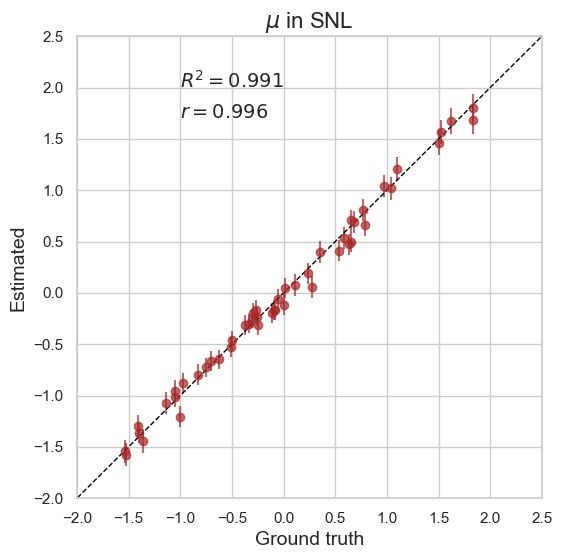

In [23]:


# ========== Recovery Line ==========
# Calculate R² and Pearson correlation coefficient
slope, intercept, r_value, p_value, std_err = linregress(ground_truth, estimated)
r_squared = r_value ** 2
pearson_corr, _ = pearsonr(ground_truth, estimated)

# ---------------- Recovery Line Plot ----------------
plt.figure(figsize=(6, 6))
sns.set(style="whitegrid")

plt.errorbar(ground_truth, estimated, yerr=error_std, fmt='o', color='brown', alpha=0.7)
plt.plot([-3, 3], [-3, 3], '--', color='black', linewidth=1)  # 45° Line

# Annotate R² and r
plt.text(-1, 2, rf"$R^2 = {r_squared:.3f}$", fontsize=14, fontstyle='italic')
plt.text(-1, 1.7, rf"$r = {pearson_corr:.3f}$", fontsize=14, fontstyle='italic')

plt.xlabel("Ground truth", fontsize=14) 
plt.ylabel("Estimated", fontsize=14)   
plt.title(r"$\mu$ in SNL", fontsize=16) 
plt.xlim(-2, 2.5)
plt.ylim(-2, 2.5)
plt.show()



In [49]:
from scipy.interpolate import CubicSpline

def plot_rank_ecdf_final(
    estimated,
    ground_truth,
    difference=True,
    rank_ecdf_color="#a34f4f",
    fill_color="grey",
    figsize=(6, 6),
    title="Rank ECDF for μ",
    band_factor=1.68  
):

    ranks = np.sum(estimated[:, None] >= ground_truth, axis=1) / len(ground_truth)
    ranks = np.clip(ranks, 1e-8, 1 - 1e-8)

    # ---- ECDF Calculation ----
    ecdf_single = np.sort(ranks)
    x_values = np.linspace(0, 1, 100)
    yy = np.arange(1, len(ecdf_single) + 1) / len(ecdf_single)
    yy_interp = np.interp(x_values, ecdf_single, yy)

    cs = CubicSpline(x_values, yy_interp)
    x_smooth = np.linspace(0, 1, 300)
    yy_smooth = cs(x_smooth)

    # ---- ECDF Difference ----
    if difference:
        yy_smooth -= x_smooth
        ylabel = "ECDF difference"
    else:
        ylabel = "ECDF"

    # ---- Simultaneous ECDF Bands ----
    n = len(ranks)
    z = np.linspace(0, 1, 300)
    c = band_factor / np.sqrt(n)
    L = z - c * np.sqrt(z * (1 - z))
    H = z + c * np.sqrt(z * (1 - z))

    if difference:
        L -= z
        H -= z
        
    y_min = np.min(L)
    y_max = np.max(H)

    plt.figure(figsize=figsize)
    sns.set(style="whitegrid")

    plt.plot(x_smooth, yy_smooth, color=rank_ecdf_color, label="Rank ECDF", linewidth=2, antialiased=True)

    plt.fill_between(z, L, H, color=fill_color, alpha=0.35, label="95% Confidence Bands")

    plt.xlabel("Fractional rank statistic", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)
    plt.xlim(0, 1)
    plt.ylim(y_min, y_max)  
    plt.legend(fontsize=10)
    plt.grid(True, linewidth=0.7, alpha=0.6)
    plt.show()


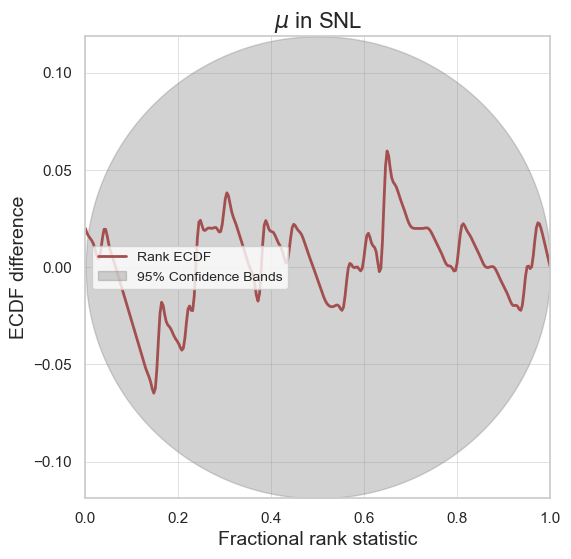

In [51]:
# Difference 模式: Rank ECDF Difference for σ²
plot_rank_ecdf_final(estimated, ground_truth, difference=True, title=r"$\mu$ in SNL")

